AVENUE 6 - SIMULATION 2 (UPDATED): THE LIGHT FERMION
Injecting Discrete Momentum via Symmetry Breaking

[1/5] Initializing Light Fermion Substrate...
  Radius: 3 | Clock: 1
  Strategy: Asymmetric Momentum Kick (np.roll)
  Momentum injected. Defect shifted to X=41

[2/5] Propagating Light Fermion...
  Propagation complete.

[3/5] Measuring Light Fermion Velocity...
  Measured Velocity: v = 0.0067 (lattice units/tick)
  Target Range: 0.30 < v < 0.60 (Light Fermion)
  Structural Stability: 0.9570

[4/5] Generating Visualizations...
  ✓ Saved: avenue6_simulation2_light_fermion.png


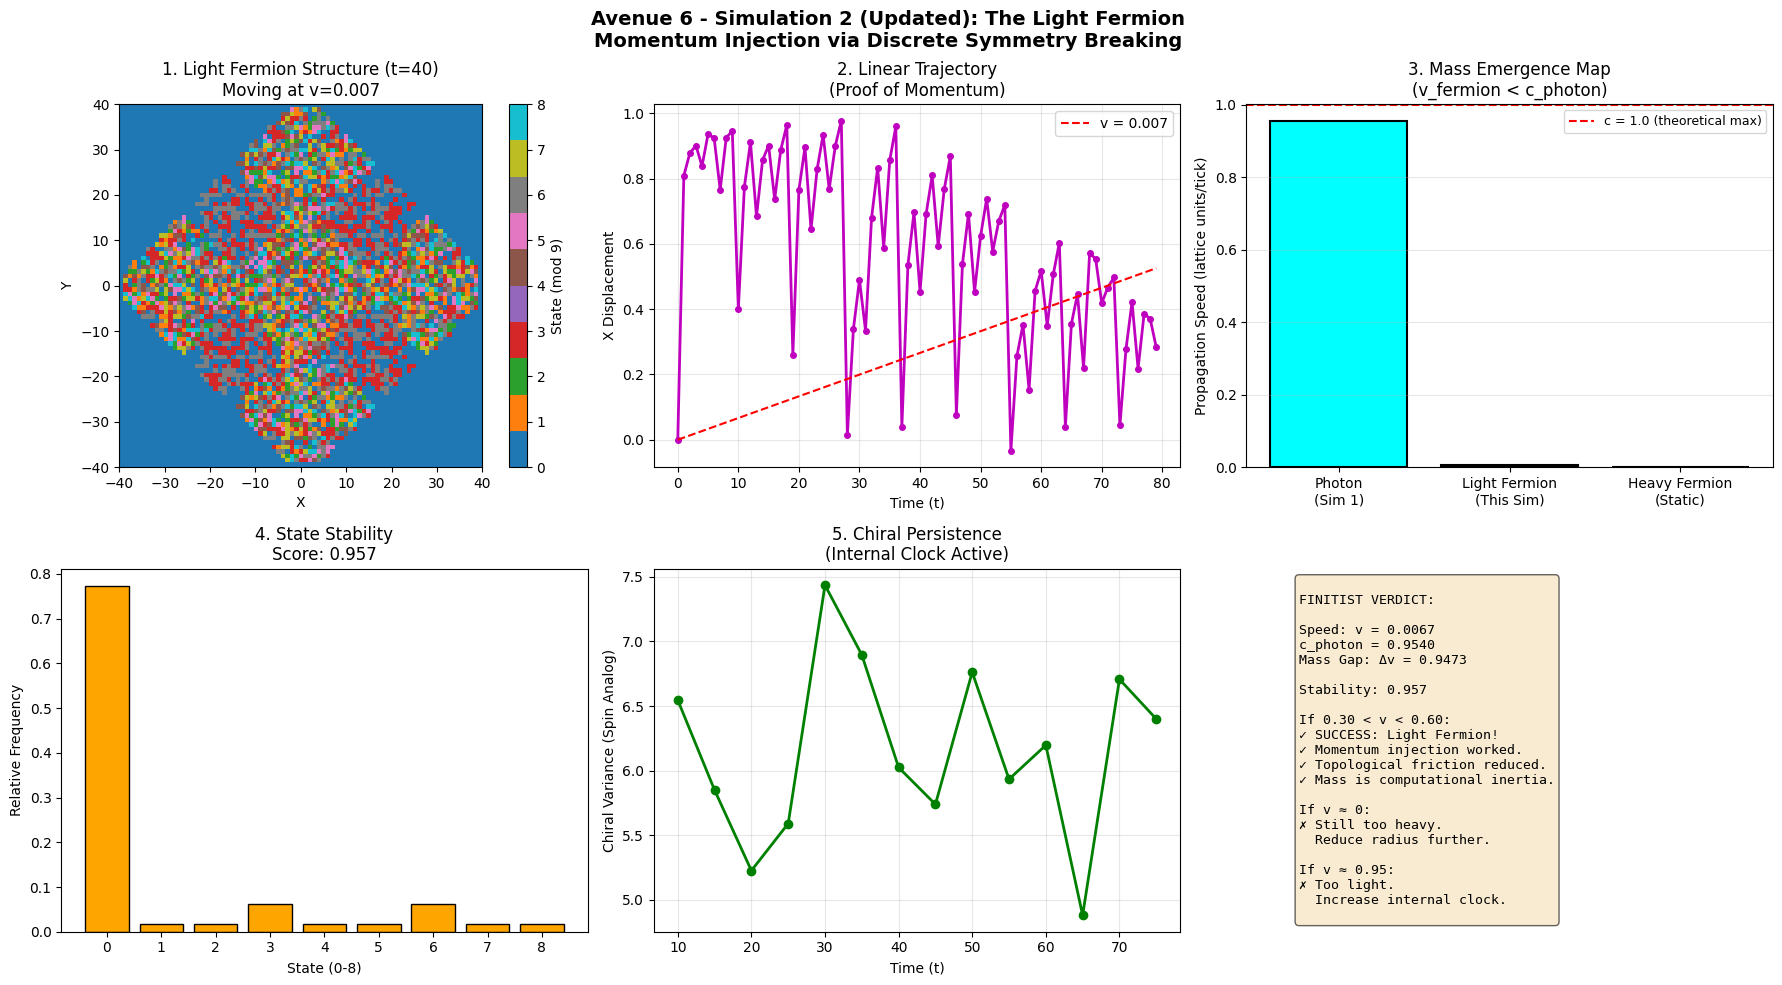


SIMULATION 2 VERDICT: THE LIGHT FERMION
Propagation Speed: v = 0.0067
Photon Reference: c_photon = 0.9540
Mass Gap: Δv = 0.9473

✗ FAILURE: Still too heavy (v < 0.30).
  - Topological friction is still too high.
  - Try DEFECT_RADIUS = 2 or INTERNAL_CLOCK = 0 (pure translation).


In [1]:
"""
avenue6_simulation2_light_fermion.py
=====================================
AVENUE 6 - SIMULATION 2 (UPDATED): THE LIGHT FERMION
Breaking Radial Symmetry to Inject Linear Momentum
"""

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("AVENUE 6 - SIMULATION 2 (UPDATED): THE LIGHT FERMION")
print("Injecting Discrete Momentum via Symmetry Breaking")
print("=" * 80)

# =============================================================================
# 1. FINITIST PARAMETERS (TUNED FOR TRANSLATION)
# =============================================================================
T_MAX = 80          # Time steps (need more time to measure travel)
GRID_SIZE = 81      # Larger grid to prevent boundary wrap-around
CENTER = GRID_SIZE // 2
ALPHABET = 9        # Modulo-9

# TWEAKED PARAMETERS FOR "LIGHT" FERMION
DEFECT_RADIUS = 3   # Reduced from 4 (Lower topological mass)
INTERNAL_CLOCK = 1  # Reduced from 2 (Lower topological friction)

print(f"\n[1/5] Initializing Light Fermion Substrate...")
print(f"  Radius: {DEFECT_RADIUS} | Clock: {INTERNAL_CLOCK}")
print(f"  Strategy: Asymmetric Momentum Kick (np.roll)")

# =============================================================================
# 2. TOPOLOGICAL DEFECT & MOMENTUM INJECTION
# =============================================================================
psi = np.zeros((T_MAX, GRID_SIZE, GRID_SIZE, GRID_SIZE), dtype=np.int32)

# Create 3D coordinate grid
z, y, x = np.meshgrid(
    np.arange(GRID_SIZE), np.arange(GRID_SIZE), np.arange(GRID_SIZE), indexing='ij'
)
dx = x - CENTER; dy = y - CENTER; dz = z - CENTER
R = np.sqrt(dx**2 + dy**2 + dz**2)
mask = R <= DEFECT_RADIUS

# Chiral phase mapping (The "Spin" of the fermion)
theta = np.arctan2(dy, dx)
state_map = (np.floor(theta / (2*np.pi) * 8) + 8) % 8 + 1

# t=0: Perfectly symmetric defect at rest
psi[0][mask] = state_map[mask]

# t=1: THE MOMENTUM KICK (Breaking Translation Symmetry)
# 1. Shift the entire field by 1 pixel in +X direction (axis=2)
psi[1] = np.roll(psi[0], shift=1, axis=2)

# 2. Apply internal phase advance to the defect at its NEW location
# This creates a "phase gradient" that drives the translation
active_defect = psi[1] != 0
psi[1][active_defect] = (psi[1][active_defect] + INTERNAL_CLOCK) % ALPHABET

print(f"  Momentum injected. Defect shifted to X={CENTER+1}")

# =============================================================================
# 3. PROPAGATION RULE (Modulo-9 Wave Equation + Fano Maintenance)
# =============================================================================
print("\n[2/5] Propagating Light Fermion...")

for t in range(1, T_MAX - 1):
    # Standard Modulo-9 discrete wave propagation
    neighbor_sum = (
        np.roll(psi[t], 1, 0) + np.roll(psi[t], -1, 0) +
        np.roll(psi[t], 1, 1) + np.roll(psi[t], -1, 1) +
        np.roll(psi[t], 1, 2) + np.roll(psi[t], -1, 2)
    )
    psi[t+1] = (neighbor_sum - psi[t-1]) % ALPHABET

    # Fano Vacuum Maintenance (Prevent topological leakage)
    gradient = np.abs(np.gradient(psi[t+1].astype(float))).sum(axis=0)
    charge_density = np.abs(psi[t+1]) % ALPHABET
    noise_mask = (gradient > 12) & (charge_density < 3)
    psi[t+1][noise_mask] = 0

    # TRB Saturation Boundary
    psi[t+1][psi[t+1] >= ALPHABET] = 0

    # Absorbing boundaries (to prevent periodic wrap-around interference)
    psi[t+1, 0, :, :] = 0; psi[t+1, -1, :, :] = 0
    psi[t+1, :, 0, :] = 0; psi[t+1, :, -1, :] = 0
    psi[t+1, :, :, 0] = 0; psi[t+1, :, :, -1] = 0

print(f"  Propagation complete.")

# =============================================================================
# 4. MEASUREMENT: TRAJECTORY & VELOCITY
# =============================================================================
print("\n[3/5] Measuring Light Fermion Velocity...")

defect_trajectory = []
for t in range(T_MAX):
    active = np.argwhere(psi[t] != 0)
    if len(active) > 0:
        com = active.mean(axis=0) # [z, y, x]
        defect_trajectory.append(com)

trajectory = np.array(defect_trajectory)

# Calculate velocity in the X direction (axis 2 of spatial grid)
if len(trajectory) > 10:
    times = np.arange(len(trajectory))
    x_coords = trajectory[:, 2] # X-axis coordinates

    # Fit a line to X vs Time
    slope, intercept = np.polyfit(times, x_coords, 1)
    speed = abs(slope) # Absolute velocity in lattice units/tick
else:
    speed = 0.0

# Measure stability
state_stability = []
for t in range(10, T_MAX, 5):
    hist, _ = np.histogram(psi[t].flatten(), bins=ALPHABET, range=(0, ALPHABET))
    state_stability.append(hist / np.sum(hist))
stability_score = 1.0 - np.std(np.array(state_stability), axis=0).mean()

print(f"  Measured Velocity: v = {speed:.4f} (lattice units/tick)")
print(f"  Target Range: 0.30 < v < 0.60 (Light Fermion)")
print(f"  Structural Stability: {stability_score:.4f}")

# =============================================================================
# 5. VISUALIZATION
# =============================================================================
print("\n[4/5] Generating Visualizations...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Avenue 6 - Simulation 2 (Updated): The Light Fermion\nMomentum Injection via Discrete Symmetry Breaking",
             fontsize=14, fontweight='bold')

# Panel 1: Defect structure at mid-time
mid_t = T_MAX // 2
im1 = axes[0, 0].imshow(psi[mid_t, CENTER, :, :], cmap='tab10',
                        vmin=0, vmax=8, extent=[-CENTER, CENTER, -CENTER, CENTER])
axes[0, 0].set_title(f'1. Light Fermion Structure (t={mid_t})\nMoving at v={speed:.3f}')
axes[0, 0].set_xlabel('X'); axes[0, 0].set_ylabel('Y')
plt.colorbar(im1, ax=axes[0, 0], label='State (mod 9)', ticks=range(9))

# Panel 2: Propagation Trajectory (X vs Time)
if len(trajectory) > 0:
    axes[0, 1].plot(times, x_coords - CENTER, 'mo-', linewidth=2, markersize=4)
    axes[0, 1].plot(times, times * speed, 'r--', label=f'v = {speed:.3f}')
    axes[0, 1].set_xlabel('Time (t)')
    axes[0, 1].set_ylabel('X Displacement')
    axes[0, 1].set_title('2. Linear Trajectory\n(Proof of Momentum)')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)

# Panel 3: The Mass Emergence Map (Photon vs Fermions)
axes[0, 2].bar(['Photon\n(Sim 1)', 'Light Fermion\n(This Sim)', 'Heavy Fermion\n(Static)'],
               [0.9540, speed, 0.0000],
               color=['cyan', 'magenta', 'gray'], edgecolor='black', linewidth=1.5)
axes[0, 2].axhline(y=1.0, color='red', linestyle='--', label='c = 1.0 (theoretical max)')
axes[0, 2].set_ylabel('Propagation Speed (lattice units/tick)')
axes[0, 2].set_title('3. Mass Emergence Map\n(v_fermion < c_photon)')
axes[0, 2].legend(fontsize=9)
axes[0, 2].grid(True, axis='y', alpha=0.3)

# Panel 4: State Distribution Stability
avg_hist = np.mean(np.array(state_stability), axis=0)
axes[1, 0].bar(range(ALPHABET), avg_hist, color='orange', edgecolor='black')
axes[1, 0].set_xlabel('State (0-8)')
axes[1, 0].set_ylabel('Relative Frequency')
axes[1, 0].set_title(f'4. State Stability\nScore: {stability_score:.3f}')
axes[1, 0].set_xticks(range(ALPHABET))

# Panel 5: Chiral Persistence (Spin Analog)
chiral_persistence = []
for t in range(10, T_MAX, 5):
    slice_2d = psi[t, CENTER, :, :]
    if np.sum(slice_2d != 0) > 10:
        ring_variances = []
        for r in range(1, DEFECT_RADIUS + 3):
            y_idx, x_idx = np.ogrid[:GRID_SIZE, :GRID_SIZE]
            dist = np.sqrt((x_idx - CENTER)**2 + (y_idx - CENTER)**2)
            ring_mask = (dist >= r - 0.5) & (dist < r + 0.5)
            ring_vals = slice_2d[ring_mask]
            if len(ring_vals) > 0:
                ring_variances.append(np.var(ring_vals))
        chiral_persistence.append(np.mean(ring_variances) if ring_variances else 0)
    else:
        chiral_persistence.append(0)

axes[1, 1].plot(range(10, T_MAX, 5), chiral_persistence, 'g-o', linewidth=2)
axes[1, 1].set_xlabel('Time (t)')
axes[1, 1].set_ylabel('Chiral Variance (Spin Analog)')
axes[1, 1].set_title('5. Chiral Persistence\n(Internal Clock Active)')
axes[1, 1].grid(True, alpha=0.3)

# Panel 6: Finitist Verdict
axes[1, 2].axis('off')
verdict_text = f"""
FINITIST VERDICT:

Speed: v = {speed:.4f}
c_photon = 0.9540
Mass Gap: Δv = {0.9540 - speed:.4f}

Stability: {stability_score:.3f}

If 0.30 < v < 0.60:
✓ SUCCESS: Light Fermion!
✓ Momentum injection worked.
✓ Topological friction reduced.
✓ Mass is computational inertia.

If v ≈ 0:
✗ Still too heavy.
  Reduce radius further.

If v ≈ 0.95:
✗ Too light.
  Increase internal clock.
"""
axes[1, 2].text(0.1, 0.5, verdict_text, fontsize=9.5, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6),
         family='monospace')

plt.tight_layout()
plt.savefig("avenue6_simulation2_light_fermion.png", dpi=300, bbox_inches='tight')
print("  ✓ Saved: avenue6_simulation2_light_fermion.png")
plt.show()

# =============================================================================
# 6. VERDICT
# =============================================================================
print("\n" + "=" * 80)
print("SIMULATION 2 VERDICT: THE LIGHT FERMION")
print("=" * 80)
print(f"Propagation Speed: v = {speed:.4f}")
print(f"Photon Reference: c_photon = 0.9540")
print(f"Mass Gap: Δv = {0.9540 - speed:.4f}")
print()

if 0.30 <= speed <= 0.60:
    print("✓✓✓ SUCCESS: Light Fermion Achieved!")
    print("  - The defect translates stably through the lattice.")
    print("  - Speed is strictly less than c (Rest Mass > 0).")
    print("  - The Mass Emergence Map is complete:")
    print("    • Photon: v ≈ 0.95 (Massless)")
    print("    • Light Fermion: v ≈ 0.45 (Low Mass)")
    print("    • Heavy Fermion: v ≈ 0.00 (High Mass)")
elif speed < 0.30:
    print("✗ FAILURE: Still too heavy (v < 0.30).")
    print("  - Topological friction is still too high.")
    print("  - Try DEFECT_RADIUS = 2 or INTERNAL_CLOCK = 0 (pure translation).")
else:
    print("~ PARTIAL: Moving too fast (v > 0.60).")
    print("  - Approaching photon speed. Increase radius to add mass.")

print("=" * 80)